# Digital Lifestyle, Productivity & Screen Behavior Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("digital_lifestyle_productivity_7000.csv")
df

,User_ID,Date,Age,Occupation,Sleep_Hours,Sleep_Quality,Screen_Time_Hours,Social_Media_Hours,Study_Work_Hours,Exercise_Minutes,Notifications_Received,Phone_Pickups,Caffeine_Cups,Stress_Score,Mood_Score,Productivity_Score,Tasks_Planned,Tasks_Completed,Weekend
0,U02207,2025-01-01,28,Analyst,6.3,8.0,6.5,2.0,10.7,42,145,94,1,4,9.0,100.0,8,4,No
1,U02443,2025-01-01,27,Teacher,7.0,8.0,6.7,1.7,9.0,15,114,87,0,6,8.0,89.1,6,2,No
2,U01081,2025-01-01,19,Freelancer,5.0,7.0,5.7,2.1,8.3,48,123,59,0,5,10.0,75.6,10,5,Yes
3,U02967,2025-01-01,28,Software Engineer,6.6,10.0,3.9,2.3,7.0,23,98,81,1,3,9.0,84.1,8,7,Yes
4,U03240,2025-01-01,49,Teacher,6.1,9.0,4.1,2.5,7.5,43,64,64,4,3,10.0,90.2,12,7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,U02989,2025-12-31,22,Freelancer,7.2,10.0,3.7,0.5,11.7,18,47,43,0,5,10.0,100.0,11,6,No
6996,U02667,2025-12-31,45,Freelancer,6.8,10.0,8.2,4.7,6.6,61,174,113,1,6,9.0,62.2,7,4,No
6997,U04676,2025-12-31,32,Software Engineer,6.9,10.0,3.5,1.4,9.8,19,115,54,1,4,8.0,94.0,5,5,No
6998,U03156,2025-12-31,42,Teacher,7.4,8.0,8.0,3.2,8.9,14,151,94,2,5,9.0,88.6,5,5,No


In [4]:
df.head()


,User_ID,Date,Age,Occupation,Sleep_Hours,Sleep_Quality,Screen_Time_Hours,Social_Media_Hours,Study_Work_Hours,Exercise_Minutes,Notifications_Received,Phone_Pickups,Caffeine_Cups,Stress_Score,Mood_Score,Productivity_Score,Tasks_Planned,Tasks_Completed,Weekend
0,U02207,2025-01-01,28,Analyst,6.3,8.0,6.5,2.0,10.7,42,145,94,1,4,9.0,100.0,8,4,No
1,U02443,2025-01-01,27,Teacher,7.0,8.0,6.7,1.7,9.0,15,114,87,0,6,8.0,89.1,6,2,No
2,U01081,2025-01-01,19,Freelancer,5.0,7.0,5.7,2.1,8.3,48,123,59,0,5,10.0,75.6,10,5,Yes
3,U02967,2025-01-01,28,Software Engineer,6.6,10.0,3.9,2.3,7.0,23,98,81,1,3,9.0,84.1,8,7,Yes
4,U03240,2025-01-01,49,Teacher,6.1,9.0,4.1,2.5,7.5,43,64,64,4,3,10.0,90.2,12,7,No


In [5]:
print(df.describe())


               Age  Sleep_Hours  Sleep_Quality  Screen_Time_Hours  \
count  7000.000000  7000.000000    6965.000000        7000.000000   
mean     39.045714     7.002443       9.067767           6.507271   
std      12.244902     1.200371       1.281132           2.174549   
min      18.000000     3.000000       3.000000           1.000000   
25%      29.000000     6.200000       8.000000           5.000000   
50%      39.000000     7.000000      10.000000           6.500000   
75%      50.000000     7.800000      10.000000           8.000000   
max      60.000000    10.000000      10.000000          14.000000   

       Social_Media_Hours  Study_Work_Hours  Exercise_Minutes  \
count         6965.000000       7000.000000       7000.000000   
mean             2.603604          8.529614         39.852143   
std              1.414123          1.973106         27.139193   
min              0.000000          1.400000          1.000000   
25%              1.500000          7.200000         2

In [6]:
print(df.shape)
print("\n",df.info())
print(df.dtypes)
# the Date column is not in the correct data type so we convert it into correct datatype .
df["Date"] = pd.to_datetime(df["Date"])

print(df.isnull().sum())



(7000, 19)
<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User_ID                 7000 non-null   str    
 1   Date                    7000 non-null   str    
 2   Age                     7000 non-null   int64  
 3   Occupation              7000 non-null   str    
 4   Sleep_Hours             7000 non-null   float64
 5   Sleep_Quality           6965 non-null   float64
 6   Screen_Time_Hours       7000 non-null   float64
 7   Social_Media_Hours      6965 non-null   float64
 8   Study_Work_Hours        7000 non-null   float64
 9   Exercise_Minutes        7000 non-null   int64  
 10  Notifications_Received  7000 non-null   int64  
 11  Phone_Pickups           7000 non-null   int64  
 12  Caffeine_Cups           7000 non-null   int64  
 13  Stress_Score            7000 non-null   int64  
 14  Mood_Score              6965 non-null   

*  35 values are missing in sleep quality column
*  35 values are missing in Social media hours 
*  35 values are missing in mood score
*  the Date column data type are incorrect

In [7]:
df.duplicated().sum()
df = df.drop_duplicates()

# Data cleaning



In [8]:
df["Sleep_Quality"] = df["Sleep_Quality"].fillna(df["Sleep_Quality"].median())
df["Social_Media_Hours"] = df["Social_Media_Hours"].fillna(df["Social_Media_Hours"].median())
df["Mood_Score"] = df["Mood_Score"].fillna(df["Mood_Score"].median())
print(df.isnull().sum())

User_ID                   0
Date                      0
Age                       0
Occupation                0
Sleep_Hours               0
Sleep_Quality             0
Screen_Time_Hours         0
Social_Media_Hours        0
Study_Work_Hours          0
Exercise_Minutes          0
Notifications_Received    0
Phone_Pickups             0
Caffeine_Cups             0
Stress_Score              0
Mood_Score                0
Productivity_Score        0
Tasks_Planned             0
Tasks_Completed           0
Weekend                   0
dtype: int64


# Features Engineering

In [9]:
# Sleep Group

def sleep_group(hours):
    if hours <= 4 :
        return "very low"
    elif hours <= 5 :
        return "low"
    elif hours <= 7 :
        return "moderate"
    elif hours <= 9 :
        return "high"
    else:
        return "very high"

df["Sleep_Group"] = df["Sleep_Hours"].apply(sleep_group)



# Screen time 
def screen_time_group (hours):
    if hours <= 3.5:
        return "low"
    elif hours <= 5 :
        return "moderate"
    elif hours <= 7:
        return "high"
    else:
        return "ver high"

df["Screen_time_group"] = df["Screen_Time_Hours"].apply(screen_time_group)



# task completion rate
df["Tasks_Completion_Rate"] = (df["Tasks_Completed"] / df["Tasks_Planned"])* 100


# Digital Dastriction Score
df["Digtal_Dastriction_Score"] = (df["Screen_Time_Hours"] * 0.5 + df["Social_Media_Hours"] * 0.5)
df




,User_ID,Date,Age,Occupation,Sleep_Hours,Sleep_Quality,Screen_Time_Hours,Social_Media_Hours,Study_Work_Hours,Exercise_Minutes,...,Stress_Score,Mood_Score,Productivity_Score,Tasks_Planned,Tasks_Completed,Weekend,Sleep_Group,Screen_time_group,Tasks_Completion_Rate,Digtal_Dastriction_Score
0,U02207,2025-01-01,28,Analyst,6.3,8.0,6.5,2.0,10.7,42,...,4,9.0,100.0,8,4,No,moderate,high,50.000000,4.25
1,U02443,2025-01-01,27,Teacher,7.0,8.0,6.7,1.7,9.0,15,...,6,8.0,89.1,6,2,No,moderate,high,33.333333,4.20
2,U01081,2025-01-01,19,Freelancer,5.0,7.0,5.7,2.1,8.3,48,...,5,10.0,75.6,10,5,Yes,low,high,50.000000,3.90
3,U02967,2025-01-01,28,Software Engineer,6.6,10.0,3.9,2.3,7.0,23,...,3,9.0,84.1,8,7,Yes,moderate,moderate,87.500000,3.10
4,U03240,2025-01-01,49,Teacher,6.1,9.0,4.1,2.5,7.5,43,...,3,10.0,90.2,12,7,No,moderate,moderate,58.333333,3.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,U02989,2025-12-31,22,Freelancer,7.2,10.0,3.7,0.5,11.7,18,...,5,10.0,100.0,11,6,No,high,moderate,54.545455,2.10
6996,U02667,2025-12-31,45,Freelancer,6.8,10.0,8.2,4.7,6.6,61,...,6,9.0,62.2,7,4,No,moderate,ver high,57.142857,6.45
6997,U04676,2025-12-31,32,Software Engineer,6.9,10.0,3.5,1.4,9.8,19,...,4,8.0,94.0,5,5,No,moderate,low,100.000000,2.45
6998,U03156,2025-12-31,42,Teacher,7.4,8.0,8.0,3.2,8.9,14,...,5,9.0,88.6,5,5,No,high,ver high,100.000000,5.60


# Descriptive Stat

# 

In [10]:
avg_Age = df["Age"].mean()
avg_sleep_hours = df["Sleep_Hours"].median()
avg_Screen_time = df["Screen_Time_Hours"].median()
avg_Social_media_hours = df["Social_Media_Hours"].median()
avg_task_Planned = df["Tasks_Planned"].median()
avg_study_hours = df["Study_Work_Hours"].mean()
avg_productivity_Score = df["Productivity_Score"].mean()





print("Average Age = ",avg_Age)
print("Average Sleep Hours = ", avg_sleep_hours)
print("Average Screen Time = ",avg_Screen_time)
print("Average Tasks Planned ", avg_task_Planned)
print("Average Study Hours = ",avg_study_hours)
print("Average Social Media Hours = ",avg_Social_media_hours)
print("Average productivity Score = ",avg_productivity_Score)


Average Age =  39.04571428571428
Average Sleep Hours =  7.0
Average Screen Time =  6.5
Average Tasks Planned  7.0
Average Study Hours =  8.529614285714286
Average Social Media Hours =  2.4
Average productivity Score =  84.07104285714287


In [11]:
# outliers in screen time  Houras
Q1 = np.quantile(df["Screen_Time_Hours"],0.25)
Q3 = np.quantile(df["Screen_Time_Hours"],0.75)
IQR = Q3 - Q1 
lower_bound = Q1 - (1.5 * IQR)
upperbound = Q3 + (1.5 * IQR)
print("Screen time Hours Q1 = ",Q1)
print("Screen time Hours Q3 = ",Q3)
print("Inter Quartile Range = ",IQR)
print("Lower bound = ", lower_bound)
print("upper_bound = ",upperbound)

outlier = []
for i in df["Screen_Time_Hours"]:
    if (i < lower_bound) | (i > upperbound ):
       outlier.append(i)

print(outlier)

Screen time Hours Q1 =  5.0
Screen time Hours Q3 =  8.0
Inter Quartile Range =  3.0
Lower bound =  0.5
upper_bound =  12.5
[12.6, 12.9, 12.9, 14.0, 13.4, 13.9, 12.6, 13.0, 13.1, 13.6, 12.9, 13.0, 13.5, 14.0, 13.9, 12.7, 13.1, 13.4, 12.8]


In [12]:
# outliers in sleep hours column
Q1 = np.quantile(df["Sleep_Hours"],0.25)
Q3 = np.quantile(df["Sleep_Hours"],0.75)
IQR = Q3 - Q1 
lower_bound = Q1 - (1.5 * IQR)
upperbound = Q3 + (1.5 * IQR)
print("Sleep Hours Q1 = ",Q1)
print("Sleep_Hours Q3 = ",Q3)
print("Inter Quartile Range = ",IQR)
print("Lower bound = ", lower_bound)
print("upper_bound = ",upperbound)

outlier = []
for i in df["Sleep_Hours"]:
    if (i < lower_bound) | (i > upperbound ):
       outlier.append(i)

print(outlier)

Sleep Hours Q1 =  6.2
Sleep_Hours Q3 =  7.8
Inter Quartile Range =  1.5999999999999996
Lower bound =  3.8000000000000007
upper_bound =  10.2
[3.2, 3.8, 3.0, 3.7, 3.7, 3.6, 3.7, 3.8, 3.3, 3.6, 3.6, 3.6, 3.6, 3.8, 3.1, 3.0, 3.5, 3.8, 3.8, 3.6, 3.0, 3.2, 3.5, 3.8, 3.3, 3.7, 3.5, 3.6, 3.0, 3.4, 3.5, 3.7]


In [13]:
# outliers in productivity
Q1 = np.quantile(df["Productivity_Score"],0.25)
Q3 = np.quantile(df["Productivity_Score"],0.75)
IQR = Q3 - Q1 
lower_bound = Q1 - (1.5 * IQR)
upperbound = Q3 + (1.5 * IQR)
print("Productivity Score Q1 = ",Q1)
print("Productivity Score Q3 = ",Q3)
print("Inter Quartile Range = ",IQR)
print("Lower bound = ", lower_bound)
print("upper_bound = ",upperbound)

outlier = []
for i in df["Productivity_Score"]:
    if (i < lower_bound) | (i > upperbound ):
       outlier.append(i)

print(outlier)


Productivity Score Q1 =  74.57499999999999
Productivity Score Q3 =  97.5
Inter Quartile Range =  22.92500000000001
Lower bound =  40.18749999999997
upper_bound =  131.88750000000002
[38.4, 38.0, 37.6, 33.7, 38.9, 37.5, 39.2, 40.1, 38.0, 33.1, 32.7, 37.9, 38.3, 39.2]


# Distribution

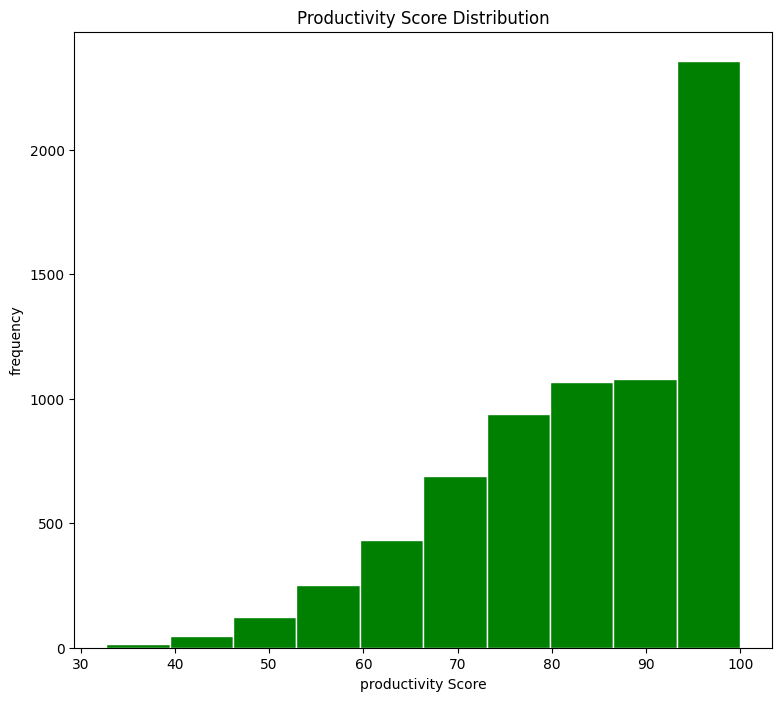

In [14]:
plt.figure(figsize=(9,8))
plt.hist(df["Productivity_Score"],bins=10,edgecolor="white",color="green")
plt.title("Productivity Score Distribution")
plt.xlabel("productivity Score")
plt.ylabel("frequency")
plt.savefig("productivity_score_dis.png",dpi=300,bbox_inches="tight")
plt.show()

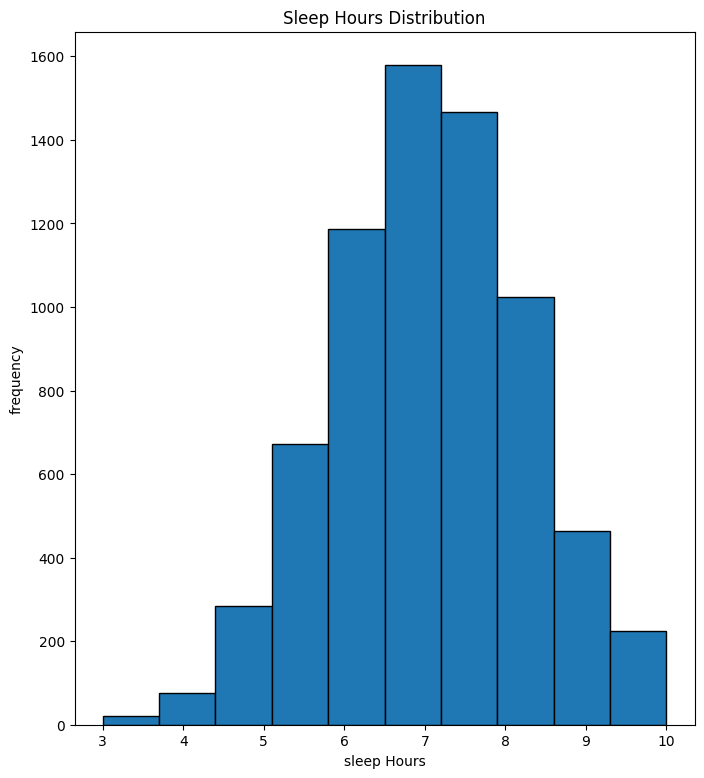

In [15]:
# sleep hours
plt.figure(figsize=(8,9))
plt.hist(df["Sleep_Hours"],bins=10,edgecolor="black")
plt.title("Sleep Hours Distribution")
plt.xlabel("sleep Hours")
plt.ylabel("frequency")
plt.savefig("sleep_hours_distri.png",dpi=300,bbox_inches="tight")
plt.show()

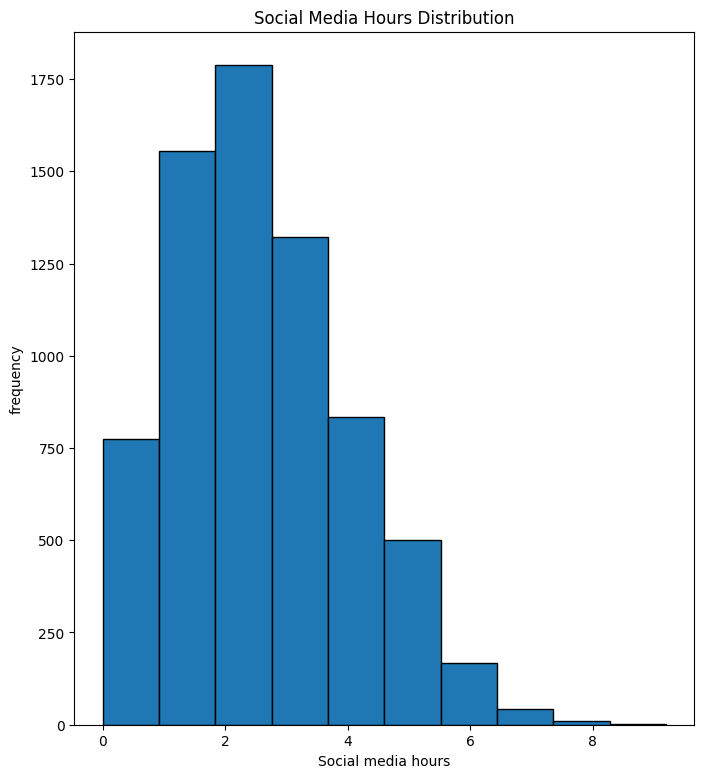

In [16]:
# social media hours
plt.figure(figsize=(8,9))
plt.hist(df["Social_Media_Hours"],bins=10,edgecolor="black")
plt.title("Social Media Hours Distribution")
plt.xlabel("Social media hours")
plt.ylabel("frequency")
plt.savefig("social_media_hours.png",dpi=300,bbox_inches="tight")
plt.show()

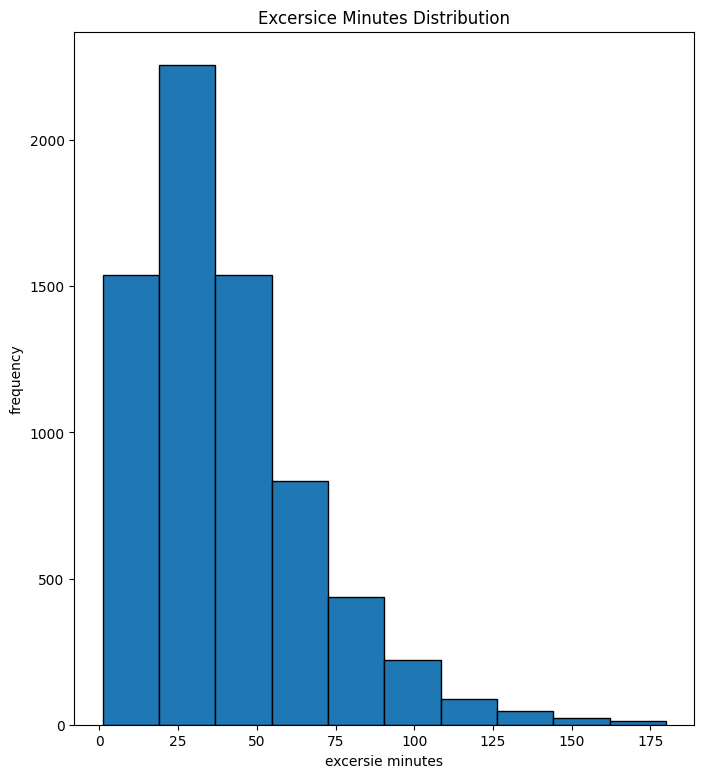

In [17]:
# excersie minutes
plt.figure(figsize=(8,9))
plt.hist(df["Exercise_Minutes"],bins=10,edgecolor="black")
plt.title("Excersice Minutes Distribution")
plt.xlabel("excersie minutes")
plt.ylabel("frequency")
plt.savefig("Excersise_minutes_dis.png",dpi=300,bbox_inches="tight")
plt.show()

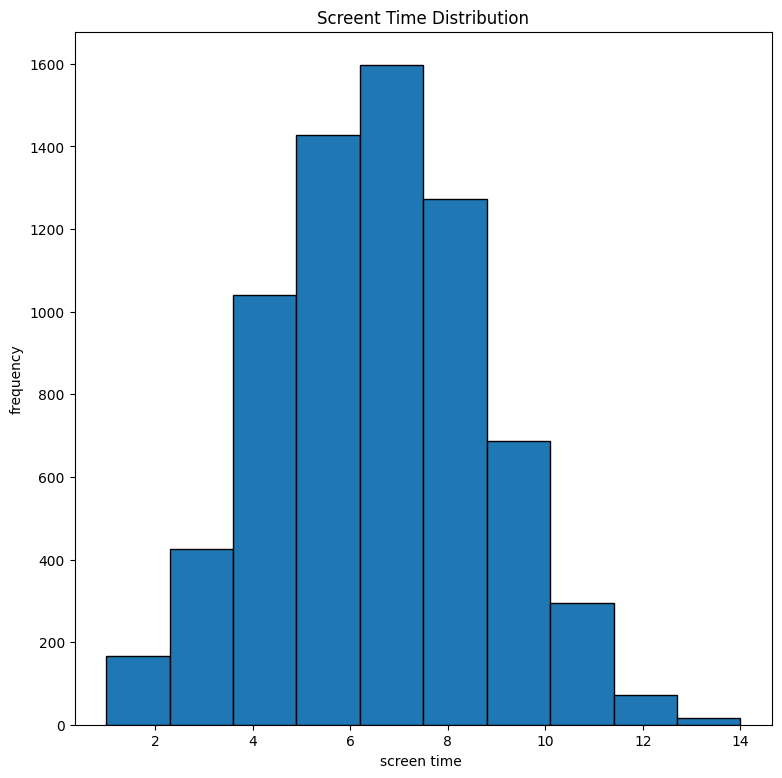

In [18]:
# screen time 
plt.figure(figsize=(9,9))
plt.hist(df["Screen_Time_Hours"],bins=10,edgecolor="black")
plt.title("Screent Time Distribution")
plt.xlabel("screen time ")
plt.ylabel("frequency")
plt.savefig("Screen_time_houre_dis.png",dpi=300,bbox_inches="tight")
plt.show()

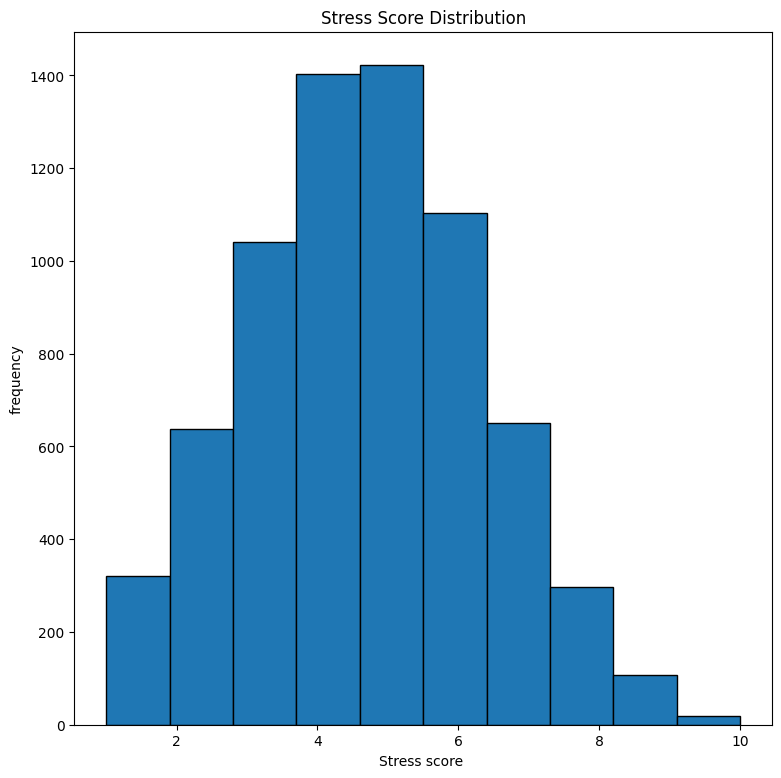

In [19]:
# stress score
plt.figure(figsize=(9,9))
plt.hist(df["Stress_Score"],bins=10,edgecolor="black")
plt.title("Stress Score Distribution")
plt.xlabel("Stress score ")
plt.ylabel("frequency")
plt.savefig("Screen_Score_dis.png",dpi=300,bbox_inches="tight")
plt.show()


In [20]:
# Sleep vs productivity relation
Sleep_corr_productivity = df["Sleep_Hours"].corr(df["Productivity_Score"])
print("Sleep hours vs productivity score = ",Sleep_corr_productivity)

# Screen time vs productivity relation
Screen_corr_productivity = df["Screen_Time_Hours"].corr(df["Productivity_Score"])
print("Screen Time vs productivity Score : ",Screen_corr_productivity)

# stress vs productivity score realtion
stress_corr_prod = df["Stress_Score"].corr(df["Productivity_Score"])
print("relation b/w stress score and productivity = ",stress_corr_prod)

# mood vs productivity Score
mood_Vs_productivity_score = df["Mood_Score"].corr(df["Productivity_Score"])
print("relation b/w mood score and productivity score : ", mood_Vs_productivity_score)


# relation b/w excersie and stress score
exe_vs_stress = df["Exercise_Minutes"].corr(df["Stress_Score"])
print("Relation b/w exercise vs stress score : ",exe_vs_stress)

Sleep hours vs productivity score =  0.3744480468140892
Screen Time vs productivity Score :  -0.6266848761624408
relation b/w stress score and productivity =  -0.7517688027450259
relation b/w mood score and productivity score :  0.5576374113330369
Relation b/w exercise vs stress score :  -0.33025039172950615


#  Relationship                  Correlation (r)   Interpretation                          

| * Sleep Hours ↔ Productivity         **0.374**  Moderate positive relationship           
| * Screen Time ↔ Productivity        **-0.627**  Strong negative relationship             
| * Stress Score ↔ Productivity       **-0.752**  Strongest negative relationship     
| * Mood Score ↔ Productivity          **0.558**  Moderate-to-strong positive relationship <br>
| * Exercise ↔ Stress                 **-0.330**  Weak-to-moderate negative relationship 


# T test
# Question 1: Is productivity significantly different between high and low screen-time users?

In [21]:
from scipy.stats import ttest_ind
median_screen = df["Screen_Time_Hours"].median()
high_scree_time = df[df["Screen_Time_Hours"] > median_screen]["Productivity_Score"]
low_Screen_time = df[df["Screen_Time_Hours"] < median_screen]["Productivity_Score"]
t_stat,p_value = ttest_ind(high_scree_time,low_Screen_time)
print("t test stat = ", t_stat)
print(" P Value",p_value)
alpha = 0.05
if p_value > alpha:
    print("Decision : we reject the null hypothesis")
    print("productivity is significantly differnt b/w low screen time and high screen time ")
else:
    print("Decision : we are fail to reject the null hypothesis")
    print("productivity is not significantlly differnt b/w low screen time and high screen time ")
    

t test stat =  -50.32894651913325
 P Value 0.0
Decision : we are fail to reject the null hypothesis
productivity is not significantlly differnt b/w low screen time and high screen time 


# Is weekend status associated with productivity category?

In [22]:
weekend = df[df["Weekend"] == "Yes"]["Productivity_Score"]
weekday = df[df["Weekend"] == "No"]["Productivity_Score"]
t_stat,p_Value = ttest_ind(weekend,weekday)
print("T test stat = ", t_stat)
print("P value = ",p_Value)
#Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Productivity is significantly different on weekends and weekdays.")
else:
    print("Fail to reject H0")
    print("There is no significant difference in productivity.")


T test stat =  0.9217273940398506
P value =  0.3567025626029527
Reject H0
Productivity is significantly different on weekends and weekdays.


# Does productivity differ between high and low digital distraction users?

In [41]:
mean_of_distraction = df["Digtal_Dastriction_Score"].median()
high_distraction = df[df["Digtal_Dastriction_Score"]> mean_of_distraction]["Productivity_Score"]
low_distraction = df[df["Digtal_Dastriction_Score"]< mean_of_distraction]["Productivity_Score"]
t_stat ,p_value = ttest_ind(high_distraction,low_distraction)
print("t test stat = ",t_stat)
print("P value = ",p_value)
alpha = 0.05
if p_value > alpha:
    print("Decision : we reject the null hypothesis")
    print("there is signifficance differnce b/w hihgh digital distraction score and low digital distraction score")
else:
    print("Decision : we are fail to reject the null hypothesis")
    print("there is no signifficance differnce b/w high digital distraction score and low digital distraction score")
    

t test stat =  -47.57943926536476
P value =  0.0
Decision : we are fail to reject the null hypothesis
there is no signifficance differnce b/w high digital distraction score and low digital distraction score
